# Bearing Anomaly Detection — NASA IMS Dataset
**Digital Systems Project — Charles Rodway, UWE Bristol**

In this notebook I am developing the bearing anomaly detection models for my predictive maintenance system. The dataset I am using is the NASA IMS bearing dataset, which contains vibration data recorded from four bearings running until failure.

The plan for this notebook is:
1. Load the dataset and understand its structure
2. Extract features from the raw vibration files
3. Explore the data to check whether the features actually capture bearing degradation
4. Decide why unsupervised detection is the right approach here
5. Compare two models — Isolation Forest and One-Class SVM
6. Evaluate how much early warning each model gives before failure
7. Train and save the final models

---
## Imports

In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from scipy import stats

from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, precision_score, recall_score

import warnings
warnings.filterwarnings('ignore')

import sklearn
print(f'scikit-learn : {sklearn.__version__}')
print(f'numpy        : {np.__version__}')

scikit-learn : 1.6.1
numpy        : 1.26.4


In [2]:
# paths
ROOT       = Path('../')
OUTPUT_DIR = Path('results/isolation_forest')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# column names — 1st test has 8 channels (2 per bearing), 2nd and 3rd have 4
COLS_8 = [
    'bearing1_ch1', 'bearing1_ch2',
    'bearing2_ch1', 'bearing2_ch2',
    'bearing3_ch1', 'bearing3_ch2',
    'bearing4_ch1', 'bearing4_ch2'
]
COLS_4 = ['bearing1_ch1', 'bearing2_ch1', 'bearing3_ch1', 'bearing4_ch1']

# each test run maps to one simulated lathe in the system
TEST_CASES = [
    {
        'name':     'lathe_1',
        'label':    'Lathe 1 — 1st Test',
        'data_dir': ROOT / 'bearing_data' / '1st_test',
        'bearings': {
            'bearing1': ['bearing1_ch1', 'bearing1_ch2'],
            'bearing2': ['bearing2_ch1', 'bearing2_ch2'],
            'bearing3': ['bearing3_ch1', 'bearing3_ch2'],
            'bearing4': ['bearing4_ch1', 'bearing4_ch2'],
        },
        'known_failures': {
            'bearing3': 'Inner Race Defect',
            'bearing4': 'Rolling Element Defect',
        }
    },
    {
        'name':     'lathe_2',
        'label':    'Lathe 2 — 2nd Test',
        'data_dir': ROOT / 'bearing_data' / '2nd_test',
        'bearings': {
            'bearing1': ['bearing1_ch1'],
            'bearing2': ['bearing2_ch1'],
            'bearing3': ['bearing3_ch1'],
            'bearing4': ['bearing4_ch1'],
        },
        'known_failures': {
            'bearing1': 'Outer Race Failure',
        }
    },
    {
        'name':     'lathe_3',
        'label':    'Lathe 3 — 3rd Test',
        'data_dir': ROOT / 'bearing_data' / '3rd_test' / 'txt',
        'bearings': {
            'bearing1': ['bearing1_ch1'],
            'bearing2': ['bearing2_ch1'],
            'bearing3': ['bearing3_ch1'],
            'bearing4': ['bearing4_ch1'],
        },
        'known_failures': {
            'bearing3': 'Outer Race Failure',
        }
    },
]

# use the first 20% of files as the healthy baseline for training
TRAIN_SPLIT = 0.2

# require 50 consecutive anomaly readings before triggering a critical alert
# this helps filter out false positives from vibration noise
ANOMALY_STREAK_THRESHOLD = 50

BEARING_COLOURS = {
    'bearing1': '#2196F3',
    'bearing2': '#4CAF50',
    'bearing3': '#F44336',
    'bearing4': '#FF9800',
}

print('Config OK')
print(f'Output dir : {OUTPUT_DIR.resolve()}')
for tc in TEST_CASES:
    files = sorted(tc['data_dir'].iterdir()) if tc['data_dir'].exists() else []
    print(f"  {tc['name']}: {len(files)} files")

Config OK
Output dir : C:\Users\Charl\Desktop\Bsc Computer Science\Year 3\DigitalSystemProject\cnc-predictive-maintenance\01_model_development\results\isolation_forest
  lathe_1: 2156 files
  lathe_2: 984 files
  lathe_3: 6324 files


---
## 1. Dataset Overview

The NASA IMS bearing dataset was collected at the University of Cincinnati. A test rig ran four bearings simultaneously at 2000 RPM under a constant radial load and recorded vibration data until the bearings failed. This was repeated three times with different outcomes each time:

| Test run | Lathe | Known failures |
|----------|-------|----------------|
| 1st_test | Lathe 1 | Bearing 3 inner race, Bearing 4 rolling element |
| 2nd_test | Lathe 2 | Bearing 1 outer race |
| 3rd_test | Lathe 3 | Bearing 3 outer race |

Each file is a 1-second snapshot recorded at 20kHz, giving 20,480 samples per file. A new file is saved every 10 minutes, so one file = 10 minutes of machine time.

The cell below loads each test case and prints a summary so we can see how many files we are working with and how many are available for training.

In [3]:
def load_file(filepath, cols_8=COLS_8, cols_4=COLS_4):
    df = pd.read_csv(filepath, sep='\t', header=None)
    n = df.shape[1]
    if n == 8:
        df.columns = cols_8
    elif n == 4:
        df.columns = cols_4
    else:
        df.columns = [f'ch{i}' for i in range(n)]
    return df


print('Dataset summary:')
print('=' * 60)
for tc in TEST_CASES:
    files = sorted([f for f in tc['data_dir'].iterdir() if f.is_file()])
    sample = load_file(files[0])
    split_idx = int(len(files) * TRAIN_SPLIT)
    print(f"\n{tc['label']}")
    print(f"  Files       : {len(files)}")
    print(f"  Channels    : {sample.shape[1]}")
    print(f"  Samples/file: {sample.shape[0]}")
    print(f"  Train files : {split_idx} (first {TRAIN_SPLIT*100:.0f}%)")
    print(f"  Test files  : {len(files) - split_idx}")
    print(f"  Failures    : {tc['known_failures']}")

Dataset summary:

Lathe 1 — 1st Test
  Files       : 2156
  Channels    : 8
  Samples/file: 20480
  Train files : 431 (first 20%)
  Test files  : 1725
  Failures    : {'bearing3': 'Inner Race Defect', 'bearing4': 'Rolling Element Defect'}

Lathe 2 — 2nd Test
  Files       : 984
  Channels    : 4
  Samples/file: 20480
  Train files : 196 (first 20%)
  Test files  : 788
  Failures    : {'bearing1': 'Outer Race Failure'}

Lathe 3 — 3rd Test
  Files       : 6324
  Channels    : 4
  Samples/file: 20480
  Train files : 1264 (first 20%)
  Test files  : 5060
  Failures    : {'bearing3': 'Outer Race Failure'}


---
## 2. Feature Extraction

Each file contains 20,480 raw vibration samples which is too much to feed directly into a model. Instead, I am reducing each file down to 11 statistical features per bearing. These are standard features used in bearing fault detection literature.

| Feature | Why it is useful |
|---------|------------------|
| Mean, Std, Max, Min | Basic signal statistics |
| RMS | Measures vibration energy — tends to increase as bearings degrade |
| Peak-to-peak | Total signal swing |
| Crest factor | Peak divided by RMS — sensitive to early impulses from surface defects |
| Kurtosis | Measures how impulsive the signal is — rises sharply when a bearing starts to develop a fault |
| Skewness | Asymmetry of the signal |
| Shape factor, Impulse factor | Dimensionless ratios used in condition monitoring |

For Lathe 1 which has two accelerometers per bearing, the features are averaged across both channels.

In [4]:
def calculate_features(signal):
    """Extract 11 statistical features from a raw vibration signal."""
    signal   = np.array(signal, dtype=np.float64)
    rms      = np.sqrt(np.mean(signal ** 2))
    max_val  = np.max(signal)
    mean_abs = np.mean(np.abs(signal))
    return {
        'mean':           np.mean(signal),
        'std':            np.std(signal),
        'max':            max_val,
        'min':            np.min(signal),
        'rms':            rms,
        'peak_to_peak':   max_val - np.min(signal),
        'crest_factor':   max_val / rms if rms != 0 else 0,
        'kurtosis':       stats.kurtosis(signal, fisher=True),
        'skewness':       stats.skew(signal),
        'shape_factor':   rms / mean_abs if mean_abs != 0 else 0,
        'impulse_factor': max_val / mean_abs if mean_abs != 0 else 0,
    }


def extract_bearing_features(filepath, channels):
    """Extract features for one bearing, averaging across channels if there are multiple."""
    df = load_file(filepath)
    channel_feats = []
    for ch in channels:
        if ch in df.columns:
            channel_feats.append(calculate_features(df[ch].values))
    if not channel_feats:
        return None
    return {k: np.mean([f[k] for f in channel_feats]) for k in channel_feats[0]}


# quick test on the first file to check the output looks right
tc    = TEST_CASES[0]
files = sorted([f for f in tc['data_dir'].iterdir() if f.is_file()])
feats = extract_bearing_features(files[0], ['bearing1_ch1', 'bearing1_ch2'])
print('Example feature vector (bearing1, first file):')
for k, v in feats.items():
    print(f'  {k:<15} {v:.6f}')

Example feature vector (bearing1, first file):
  mean            -0.094236
  std             0.075885
  max             0.544500
  min             -0.642000
  rms             0.121053
  peak_to_peak    1.186500
  crest_factor    4.539962
  kurtosis        2.067523
  skewness        0.095062
  shape_factor    1.184280
  impulse_factor  5.359076


In [31]:
# extract features for all lathes — this takes a few minutes
all_features = {}

for tc in TEST_CASES:
    lathe_name = tc['name']
    files      = sorted([f for f in tc['data_dir'].iterdir() if f.is_file()])
    print(f"\nExtracting features: {tc['label']} ({len(files)} files)")
    all_features[lathe_name] = {}

    for bearing_name, channels in tc['bearings'].items():
        rows = []
        for i, filepath in enumerate(files):
            feats = extract_bearing_features(filepath, channels)
            if feats:
                feats['reading']  = i + 1
                feats['filename'] = filepath.name
                feats['progress'] = (i / len(files)) * 100
                rows.append(feats)
        df = pd.DataFrame(rows)
        all_features[lathe_name][bearing_name] = df
        print(f'  {bearing_name}: {len(df)} readings extracted')

print('\nDone.')


Extracting features: Lathe 1 — 1st Test (2156 files)
  bearing2: 2156 readings extracted
  bearing3: 2156 readings extracted
  bearing4: 2156 readings extracted

Extracting features: Lathe 2 — 2nd Test (984 files)
  bearing1: 984 readings extracted
  bearing2: 984 readings extracted
  bearing3: 984 readings extracted
  bearing4: 984 readings extracted

Extracting features: Lathe 3 — 3rd Test (6324 files)
  bearing1: 6324 readings extracted
  bearing2: 6324 readings extracted
  bearing3: 6324 readings extracted
  bearing4: 6324 readings extracted

Done.


---
## 3. Exploratory Data Analysis

Before training anything, I want to check whether the features I have extracted actually show bearing degradation over time. Kurtosis and RMS are the two features most commonly mentioned in the literature for early fault detection, so I will plot both over the course of each test run.

The expectation is that the bearings we know failed should show a clear rise towards the end of the test, while the healthy bearings should stay relatively flat. If the features do not show this pattern at all then the model will not be able to detect anything useful.

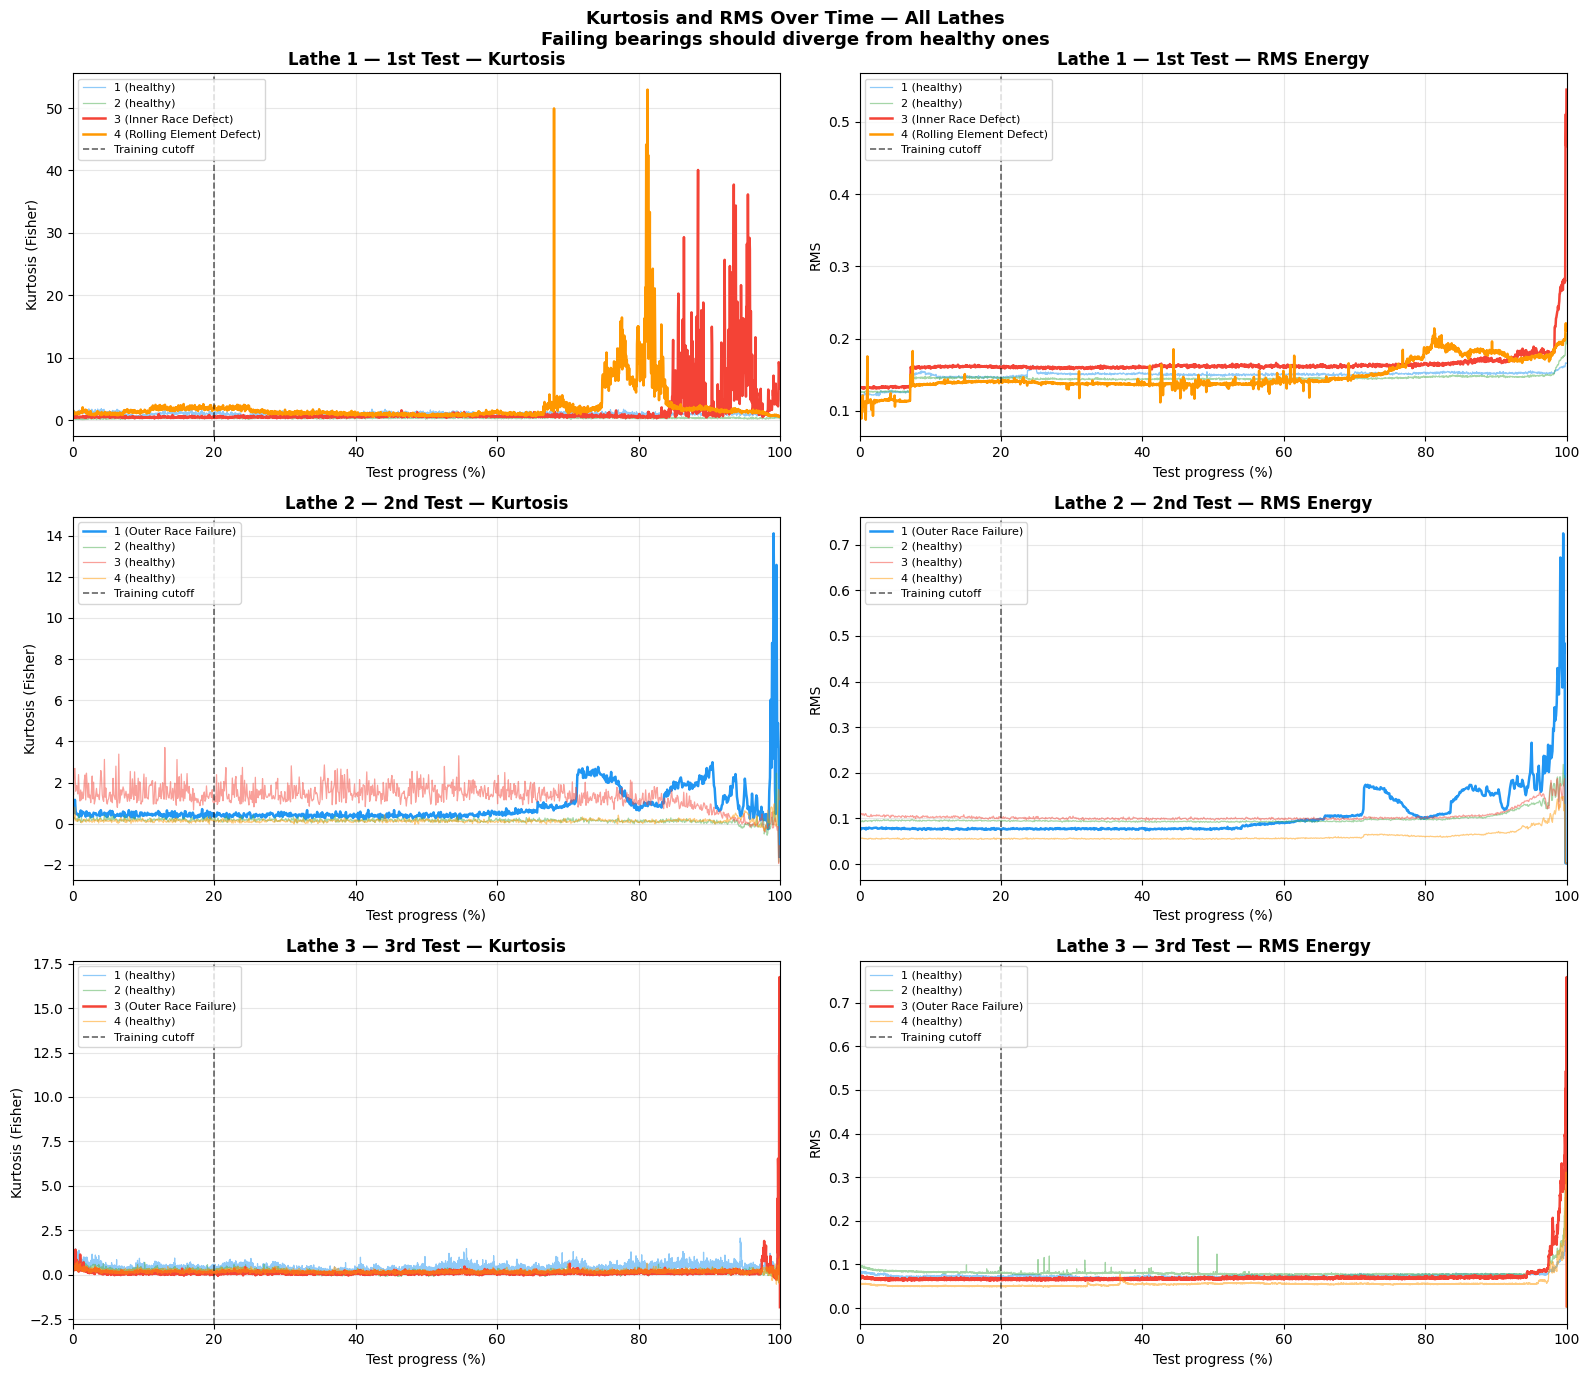

Saved: eda_feature_evolution.png


In [32]:
fig, axes = plt.subplots(3, 2, figsize=(16, 14))
fig.suptitle('Kurtosis and RMS Over Time — All Lathes\n'
             'Failing bearings should diverge from healthy ones',
             fontsize=13, fontweight='bold')

for row, tc in enumerate(TEST_CASES):
    lathe_name     = tc['name']
    known_failures = tc['known_failures']
    split_pct      = TRAIN_SPLIT * 100

    ax_kurt = axes[row, 0]
    ax_rms  = axes[row, 1]

    for bearing_name, df in all_features[lathe_name].items():
        colour  = BEARING_COLOURS[bearing_name]
        is_fail = bearing_name in known_failures
        lw      = 1.8 if is_fail else 0.9
        alpha   = 1.0 if is_fail else 0.5
        label   = f"{bearing_name[-1]} ({known_failures[bearing_name]})" if is_fail else f"{bearing_name[-1]} (healthy)"

        ax_kurt.plot(df['progress'], df['kurtosis'], color=colour, lw=lw, alpha=alpha, label=label)
        ax_rms.plot(df['progress'],  df['rms'],      color=colour, lw=lw, alpha=alpha, label=label)

    for ax in [ax_kurt, ax_rms]:
        ax.axvline(x=split_pct, color='black', linestyle='--', linewidth=1.2,
                   alpha=0.6, label='Training cutoff')
        ax.set_xlabel('Test progress (%)')
        ax.set_xlim(0, 100)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8, loc='upper left')

    ax_kurt.set_ylabel('Kurtosis (Fisher)')
    ax_kurt.set_title(f"{tc['label']} — Kurtosis", fontweight='bold')
    ax_rms.set_ylabel('RMS')
    ax_rms.set_title(f"{tc['label']} — RMS Energy", fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_feature_evolution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eda_feature_evolution.png')

---
## 4. Why Unsupervised Detection?

The obvious question at this point is why not just train a classifier to detect faults directly.

The problem is the IMS dataset does not have the right structure for supervised learning. There are only three bearing failures across the entire dataset, each a different fault type. With only one example of each fault type there is no way to train a classifier that could generalise — you would essentially be memorising one example and hoping new faults look identical.

There are also no labels for individual files. We know which bearings failed and what the fault type was, but there is no timestamp marking when the fault actually started. So we cannot even label the data properly.

Unsupervised anomaly detection solves both of these problems. The idea is to train only on the healthy data from the start of each test run, and then flag anything that looks different from that baseline. No labels needed, and it does not matter that we only have three failure examples.

---
## 5. Model Comparison — Isolation Forest vs One-Class SVM

I am comparing two unsupervised approaches to see which works better on this data.

**Isolation Forest** works by randomly partitioning the feature space using decision trees. Anomalies are data points that get isolated in fewer splits than normal points — they are easier to separate because they are statistically different from the rest of the data.

**One-Class SVM** fits a boundary around the training data in a higher-dimensional space. At inference time, points that fall outside that boundary are classified as anomalies.

Both models are trained on the first 20% of each bearing's readings (the healthy baseline) and then evaluated on the full run. The most important metric here is the false positive rate on healthy bearings — if a model keeps flagging healthy bearings as anomalous, it is not going to be useful in practice because the alerts will just be ignored.

Models trained. Plotting false positive rates...


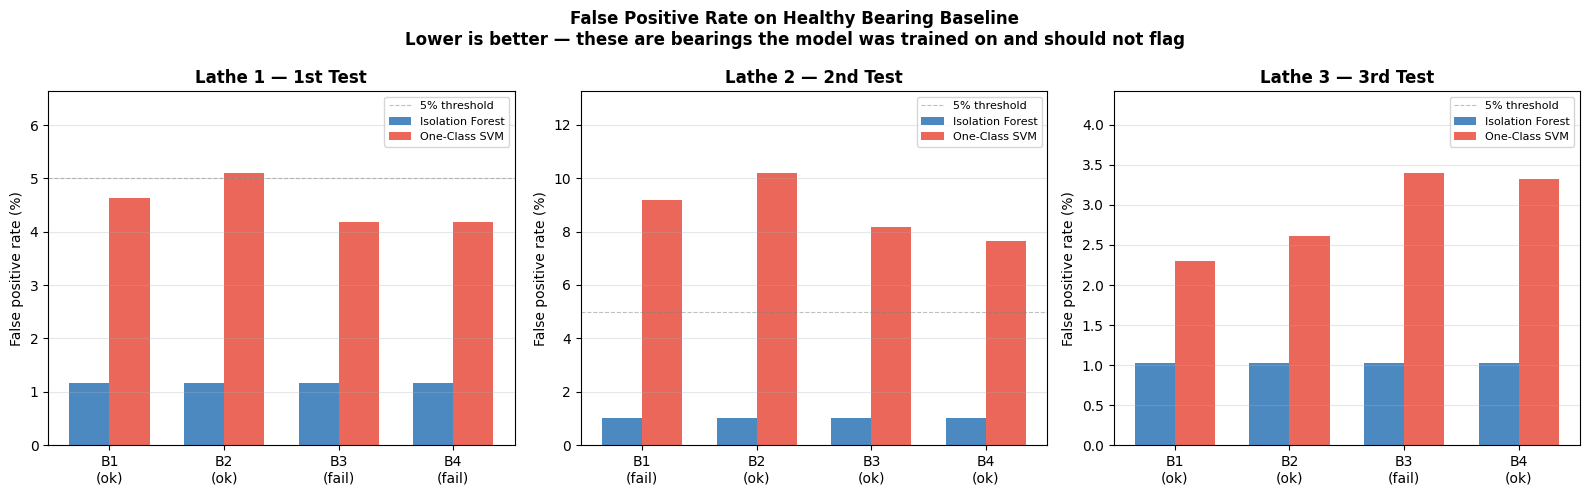

Saved: model_comparison_fp_rates.png


In [33]:
import time

comparison_results = {}

FEATURE_NAMES = ['mean', 'std', 'max', 'min', 'rms',
                 'peak_to_peak', 'crest_factor', 'kurtosis',
                 'skewness', 'shape_factor', 'impulse_factor']

# train both models on all bearings and store results
for tc in TEST_CASES:
    lathe_name = tc['name']
    comparison_results[lathe_name] = {}

    for bearing_name, df in all_features[lathe_name].items():
        n_train   = int(len(df) * TRAIN_SPLIT)
        X_all     = df[FEATURE_NAMES].values
        X_train   = X_all[:n_train]

        scaler    = StandardScaler()
        X_train_s = scaler.fit_transform(X_train)
        X_all_s   = scaler.transform(X_all)

        bearing_results = {}

        # train and evaluate Isolation Forest
        iforest = IsolationForest(contamination=0.01, n_estimators=100,
                                  random_state=42, n_jobs=-1)
        iforest.fit(X_train_s)
        if_preds  = iforest.predict(X_all_s)
        if_scores = iforest.decision_function(X_all_s)

        bearing_results['IsolationForest'] = {
            'model':                iforest,
            'scaler':               scaler,
            'preds':                if_preds,
            'scores':               if_scores,
            'anomaly_rate_healthy': np.mean(if_preds[:n_train] == -1) * 100,
            'anomaly_rate_test':    np.mean(if_preds[n_train:] == -1) * 100,
        }

        # train and evaluate One-Class SVM
        ocsvm = OneClassSVM(kernel='rbf', nu=0.01, gamma='scale')
        ocsvm.fit(X_train_s)
        svm_preds  = ocsvm.predict(X_all_s)
        svm_scores = ocsvm.decision_function(X_all_s)

        bearing_results['OneClassSVM'] = {
            'model':                ocsvm,
            'scaler':               scaler,
            'preds':                svm_preds,
            'scores':               svm_scores,
            'anomaly_rate_healthy': np.mean(svm_preds[:n_train] == -1) * 100,
            'anomaly_rate_test':    np.mean(svm_preds[n_train:] == -1) * 100,
        }

        is_fail = bearing_name in tc['known_failures']
        comparison_results[lathe_name][bearing_name] = {
            'results':      bearing_results,
            'n_train':      n_train,
            'df':           df,
            'is_failure':   is_fail,
            'failure_type': tc['known_failures'].get(bearing_name, None),
        }

print('Models trained. Plotting false positive rates...')

# bar chart comparing false positive rates on healthy bearings
# a high false positive rate on healthy data means the model raises
# alerts on bearings that are fine, which makes it unusable in practice
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('False Positive Rate on Healthy Bearing Baseline\n'
             'Lower is better — these are bearings the model was trained on and should not flag',
             fontsize=12, fontweight='bold')

bar_width = 0.35
colours   = {'IsolationForest': '#2E75B6', 'OneClassSVM': '#E74C3C'}

for col, tc in enumerate(TEST_CASES):
    ax         = axes[col]
    lathe_name = tc['name']

    bearing_labels = []
    if_rates       = []
    svm_rates      = []

    for bearing_name, br in comparison_results[lathe_name].items():
        is_fail = br['is_failure']
        label   = f"B{bearing_name[-1]}\n({'fail' if is_fail else 'ok'})"
        bearing_labels.append(label)
        if_rates.append(br['results']['IsolationForest']['anomaly_rate_healthy'])
        svm_rates.append(br['results']['OneClassSVM']['anomaly_rate_healthy'])

    x = np.arange(len(bearing_labels))

    ax.bar(x - bar_width/2, if_rates,  bar_width, label='Isolation Forest',
           color=colours['IsolationForest'], alpha=0.85)
    ax.bar(x + bar_width/2, svm_rates, bar_width, label='One-Class SVM',
           color=colours['OneClassSVM'], alpha=0.85)

    ax.set_title(tc['label'], fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(bearing_labels)
    ax.set_ylabel('False positive rate (%)')
    ax.set_ylim(0, max(max(if_rates), max(svm_rates)) * 1.3)
    ax.axhline(y=5, color='gray', linestyle='--', alpha=0.5, linewidth=0.8,
               label='5% threshold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'model_comparison_fp_rates.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: model_comparison_fp_rates.png')


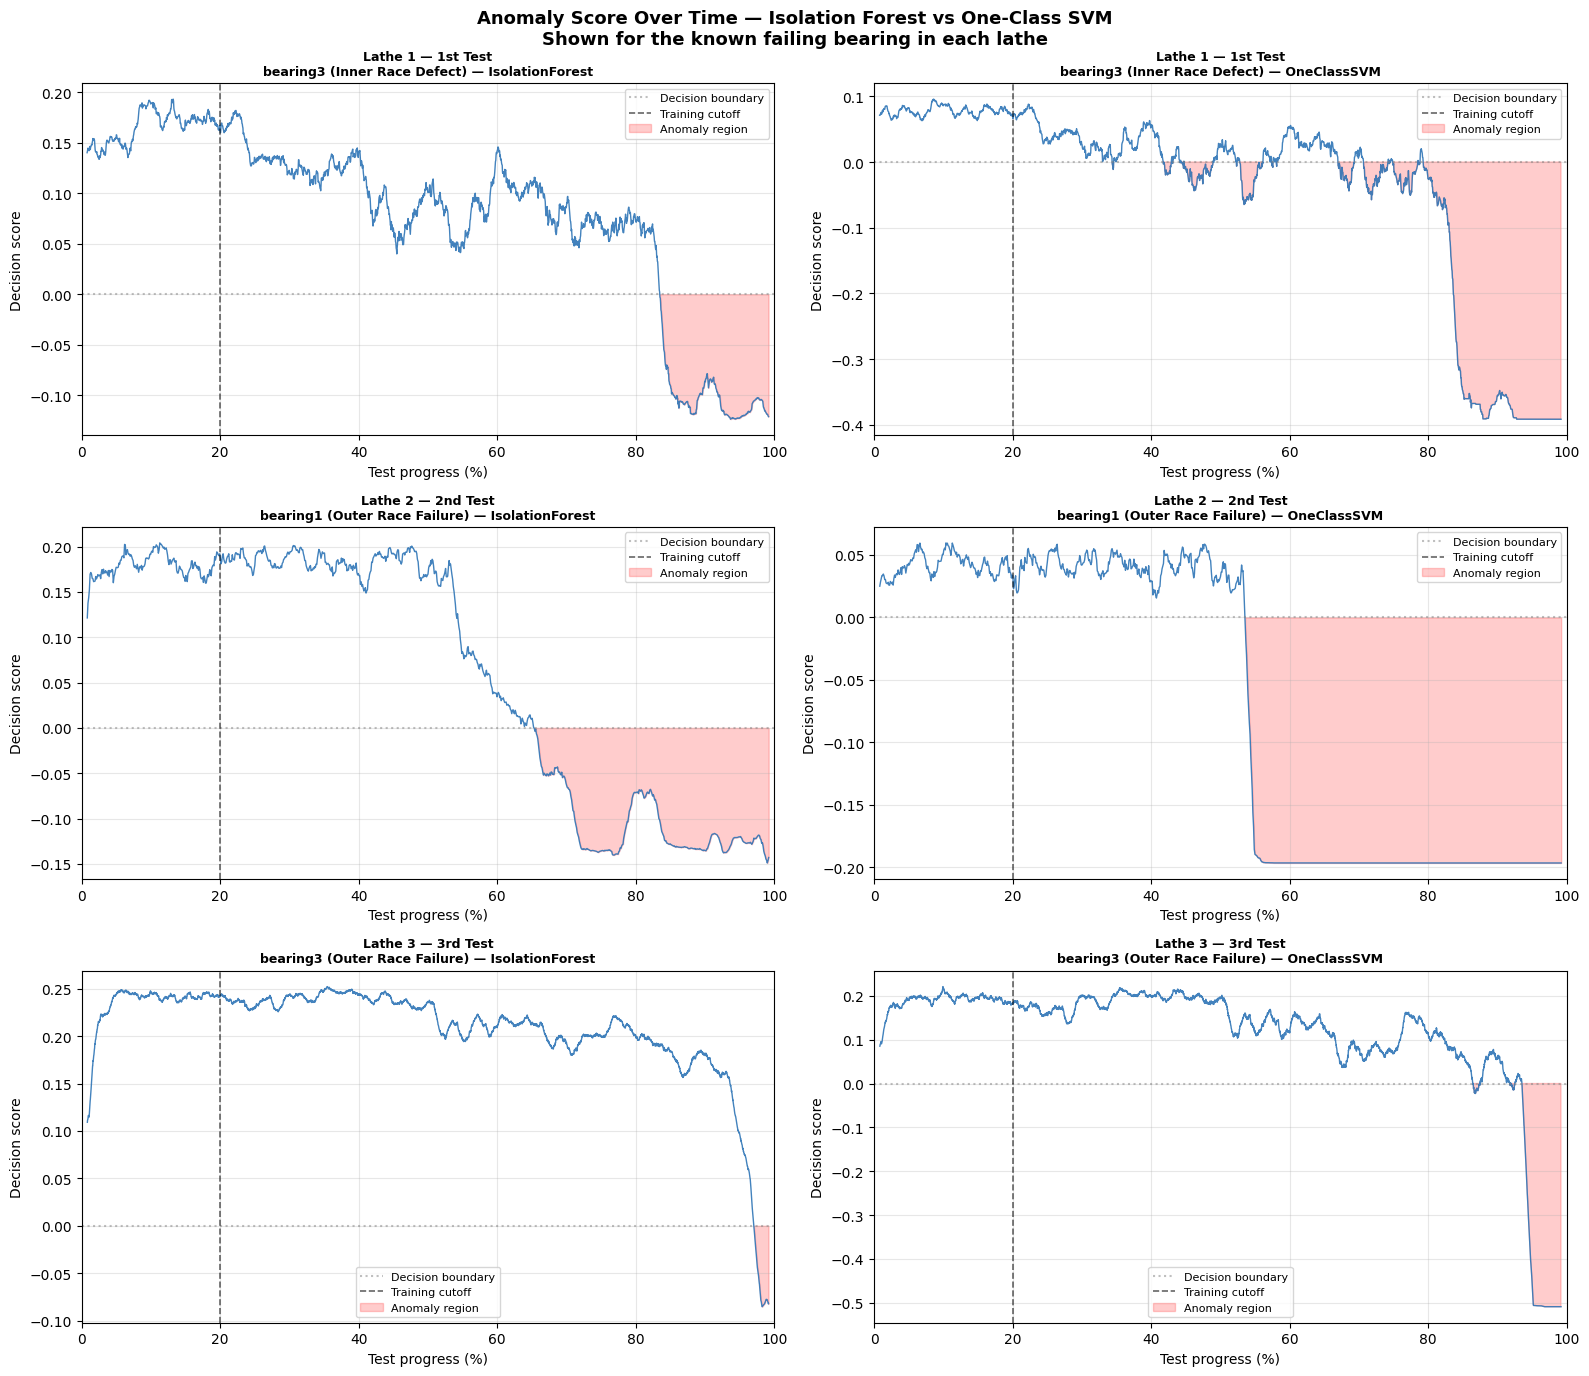

Saved: model_comparison_scores.png


In [34]:
# plot anomaly scores over time for the known failing bearing per lathe
fail_bearings = {
    'lathe_1': 'bearing3',
    'lathe_2': 'bearing1',
    'lathe_3': 'bearing3',
}

fig, axes = plt.subplots(3, 2, figsize=(16, 14))
fig.suptitle('Anomaly Score Over Time — Isolation Forest vs One-Class SVM\n'
             'Shown for the known failing bearing in each lathe',
             fontsize=13, fontweight='bold')

for row, tc in enumerate(TEST_CASES):
    lathe_name   = tc['name']
    bearing_name = fail_bearings[lathe_name]
    br           = comparison_results[lathe_name][bearing_name]
    df           = br['df']
    split_pct    = TRAIN_SPLIT * 100

    for col, model_name in enumerate(['IsolationForest', 'OneClassSVM']):
        ax     = axes[row, col]
        scores = br['results'][model_name]['scores']
        window = max(1, len(scores) // 60)
        smooth = pd.Series(scores).rolling(window, center=True).mean()

        ax.plot(df['progress'], smooth, color='#2E75B6', linewidth=1.0, alpha=0.9)
        ax.axhline(y=0, color='gray', linestyle=':', alpha=0.5, label='Decision boundary')
        ax.axvline(x=split_pct, color='black', linestyle='--', linewidth=1.2,
                   alpha=0.6, label='Training cutoff')
        ax.fill_between(df['progress'], smooth, 0,
                        where=smooth < 0, alpha=0.2, color='red', label='Anomaly region')
        ax.set_xlabel('Test progress (%)')
        ax.set_ylabel('Decision score')
        ax.set_title(f"{tc['label']}\n{bearing_name} ({br['failure_type']}) — {model_name}",
                     fontweight='bold', fontsize=9)
        ax.set_xlim(0, 100)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'model_comparison_scores.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: model_comparison_scores.png')

---
## 5b. Early Warning Evaluation

One of the key questions for a predictive maintenance system is how much warning time the model gives before a bearing actually fails. My supervisor specifically asked me to evaluate this, so this section looks at how early each model detects the known failures.

The way I am measuring this is by finding the first point after the training cutoff where the model produces a sustained run of anomaly predictions — specifically 50 consecutive anomaly readings. That threshold is the same one used in the deployed system. The number of readings remaining after that point is the warning time. Since each reading is 10 minutes of machine time, warning time in hours = remaining readings × 10 / 60.

One important limitation to note: the IMS dataset does not have a ground truth timestamp for when each fault actually started. So the warning time here is time before the end of the test run, not confirmed time before actual fault onset. It is still a useful comparison between the two models, but it is not the same as saying the model would give X hours warning in a real deployment.

In [35]:
print('Detection latency comparison (streak threshold =', ANOMALY_STREAK_THRESHOLD, ')')
print('=' * 90)
print(f"{'Lathe':<10} {'Bearing':<12} {'Failure type':<25} {'Model':<20} {'Latency (readings)':>20} {'Warning time (hrs)':>20}")
print('-' * 90)

for tc in TEST_CASES:
    lathe_name = tc['name']
    for bearing_name, br in comparison_results[lathe_name].items():
        if not br['is_failure']:
            continue
        n_train = br['n_train']

        for model_name, res in br['results'].items():
            # look for the first streak of 50 consecutive anomalies after training
            preds    = res['preds'][n_train:]
            streak   = 0
            alert_at = None
            for idx, p in enumerate(preds):
                if p == -1:
                    streak += 1
                    if streak >= ANOMALY_STREAK_THRESHOLD:
                        alert_at = idx + 1
                        break
                else:
                    streak = 0

            if alert_at is not None:
                remaining   = len(preds) - alert_at
                warning_hrs = (remaining * 10) / 60
                latency_str = str(alert_at)
                warning_str = f'{warning_hrs:.1f}'
            else:
                latency_str = 'Never'
                warning_str = 'N/A'

            print(f"{lathe_name:<10} {bearing_name:<12} {br['failure_type']:<25} "
                  f"{model_name:<20} {latency_str:>20} {warning_str:>20}")

print('=' * 90)

Detection latency comparison (streak threshold = 50 )
Lathe      Bearing      Failure type              Model                  Latency (readings)   Warning time (hrs)
------------------------------------------------------------------------------------------
lathe_1    bearing3     Inner Race Defect         IsolationForest                      1497                 38.0
lathe_1    bearing3     Inner Race Defect         OneClassSVM                          1421                 50.7
lathe_1    bearing4     Rolling Element Defect    IsolationForest                      1228                 82.8
lathe_1    bearing4     Rolling Element Defect    OneClassSVM                           897                138.0
lathe_2    bearing1     Outer Race Failure        IsolationForest                       534                 42.3
lathe_2    bearing1     Outer Race Failure        OneClassSVM                           386                 67.0
lathe_3    bearing3     Outer Race Failure        IsolationFores

---
## 6. Model Selection

Based on the results above, I am going with **Isolation Forest** for the final models.

The main reason is the false positive rate on the healthy bearing baseline. Looking at the bar chart, Isolation Forest stays consistently between 1-1.2% across every bearing on all three lathes. One-Class SVM ranges from 4-5% on Lathe 1, 8-10% on Lathe 2, and 2-3% on Lathe 3. That inconsistency is a problem on its own — you want a model that behaves predictably across different machines.

The early warning results are more nuanced. OC-SVM actually appears to give longer warning times — 50.7 hours vs 38 hours for Lathe 1 bearing 3, and 138 hours vs 82.8 hours for Lathe 1 bearing 4 for example. But this is misleading. Because OC-SVM has a higher false positive rate it triggers its streak of 50 consecutive anomalies earlier — not because it has genuinely detected degradation sooner, but because it is flagging readings more aggressively. A model that raises constant false alarms will be ignored by maintenance engineers in practice, so that apparent advantage is not real.

The Isolation Forest early warning results are still meaningful on their own terms. Lathe 2 bearing 1 (outer race failure) gives 42.3 hours warning, and Lathe 1 bearing 4 (rolling element) gives 82.8 hours. That is enough time to order a replacement part and schedule a planned maintenance stop rather than dealing with an emergency breakdown. Lathe 3 bearing 3 only gives 19.2 hours warning, but looking at the anomaly score plot that bearing fails very suddenly at the end of the test — there is genuinely not much warning to give for that failure mode regardless of which model is used.

One caveat worth being clear about: these warning times are measured from when the model triggers to the end of the test run, not to a confirmed fault onset timestamp. The IMS dataset does not provide that information, so the figures represent time before the test ended rather than confirmed time before actual failure.

On cost comparison — Without access to real maintenance cost figures a proper quantitative comparison is not possible. Qualitatively, the lower false positive rate of Isolation Forest means fewer unnecessary callouts, and the early warning on gradual failures gives the opportunity for planned rather than emergency maintenance, both of which have clear cost benefits.

---
## 7. Train and Save Final Models

Now training the final Isolation Forest models on all three lathes and saving them as pickle files. Each bearing gets its own model saved in a subfolder per lathe:

```
results/isolation_forest/
├── lathe_1/
│   ├── bearing1_model.pkl
│   ├── bearing2_model.pkl
│   ├── bearing3_model.pkl
│   └── bearing4_model.pkl
├── lathe_2/
└── lathe_3/
```

These model files are then copied into the system folder and loaded by the Raspberry Pi containers at runtime.

In [36]:
print('Training final Isolation Forest models...')
print('=' * 60)

for tc in TEST_CASES:
    lathe_name = tc['name']
    files      = sorted([f for f in tc['data_dir'].iterdir() if f.is_file()])
    n_train    = int(len(files) * TRAIN_SPLIT)

    lathe_dir = OUTPUT_DIR / lathe_name
    lathe_dir.mkdir(parents=True, exist_ok=True)

    print(f"\n{tc['label']}")
    print(f"  Output : {lathe_dir}")
    print(f"  Training on {n_train} files, {len(files) - n_train} held out")

    all_bearing_results = {}

    for bearing_name, channels in tc['bearings'].items():
        df      = all_features[lathe_name][bearing_name]
        X_all   = df[FEATURE_NAMES].values
        X_train = X_all[:n_train]

        model = IsolationForest(
            contamination=0.01,
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        )
        model.fit(X_train)

        preds  = model.predict(X_all)
        scores = model.decision_function(X_all)

        results_df = df.copy()
        results_df['is_anomaly']    = (preds == -1)
        results_df['anomaly_score'] = scores

        # save results csv
        csv_path = lathe_dir / f'{bearing_name}_results.csv'
        results_df.to_csv(csv_path, index=False)

        # save model bundle with everything needed for inference
        bundle = {
            'model':           model,
            'feature_names':   FEATURE_NAMES,
            'train_split':     TRAIN_SPLIT,
            'n_train_samples': n_train,
            'channels':        channels,
            'bearing':         bearing_name,
            'lathe':           lathe_name,
        }
        model_path = lathe_dir / f'{bearing_name}_model.pkl'
        with open(model_path, 'wb') as f:
            pickle.dump(bundle, f)

        all_bearing_results[bearing_name] = results_df
        anomaly_pct = results_df['is_anomaly'].mean() * 100
        print(f'  {bearing_name}: saved  ({anomaly_pct:.1f}% anomalous overall)')

    # build overall machine health csv combining all four bearings
    overall_rows = []
    n_readings = min(len(df) for df in all_bearing_results.values())
    for i in range(n_readings):
        row = {'reading': i + 1}
        scores_i    = []
        anomalies_i = []
        for bn, rdf in all_bearing_results.items():
            if i < len(rdf):
                row[f'{bn}_score']    = rdf.iloc[i]['anomaly_score']
                row[f'{bn}_anomaly']  = rdf.iloc[i]['is_anomaly']
                row[f'{bn}_kurtosis'] = rdf.iloc[i].get('kurtosis', 0)
                row[f'{bn}_rms']      = rdf.iloc[i].get('rms', 0)
                scores_i.append(rdf.iloc[i]['anomaly_score'])
                anomalies_i.append(rdf.iloc[i]['is_anomaly'])
        row['machine_score']           = min(scores_i) if scores_i else 0
        row['machine_anomaly']         = any(anomalies_i)
        row['anomalous_bearing_count'] = sum(anomalies_i)
        overall_rows.append(row)

    overall_df   = pd.DataFrame(overall_rows)
    overall_path = lathe_dir / 'overall_results.csv'
    overall_df.to_csv(overall_path, index=False)
    print(f'  Overall results saved: {overall_path.name}')

print('\n' + '=' * 60)
print('All models saved.')
print(f'Output: {OUTPUT_DIR.resolve()}')

Training final Isolation Forest models...

Lathe 1 — 1st Test
  Output : results\isolation_forest\lathe_1
  Training on 431 files, 1725 held out
  bearing1: saved  (4.8% anomalous overall)
  bearing2: saved  (9.0% anomalous overall)
  bearing3: saved  (26.0% anomalous overall)
  bearing4: saved  (29.5% anomalous overall)
  Overall results saved: overall_results.csv

Lathe 2 — 2nd Test
  Output : results\isolation_forest\lathe_2
  Training on 196 files, 788 held out
  bearing1: saved  (36.2% anomalous overall)
  bearing2: saved  (6.8% anomalous overall)
  bearing3: saved  (1.4% anomalous overall)
  bearing4: saved  (4.9% anomalous overall)
  Overall results saved: overall_results.csv

Lathe 3 — 3rd Test
  Output : results\isolation_forest\lathe_3
  Training on 1264 files, 5060 held out
  bearing1: saved  (1.6% anomalous overall)
  bearing2: saved  (2.6% anomalous overall)
  bearing3: saved  (3.1% anomalous overall)
  bearing4: saved  (5.1% anomalous overall)
  Overall results saved: ove

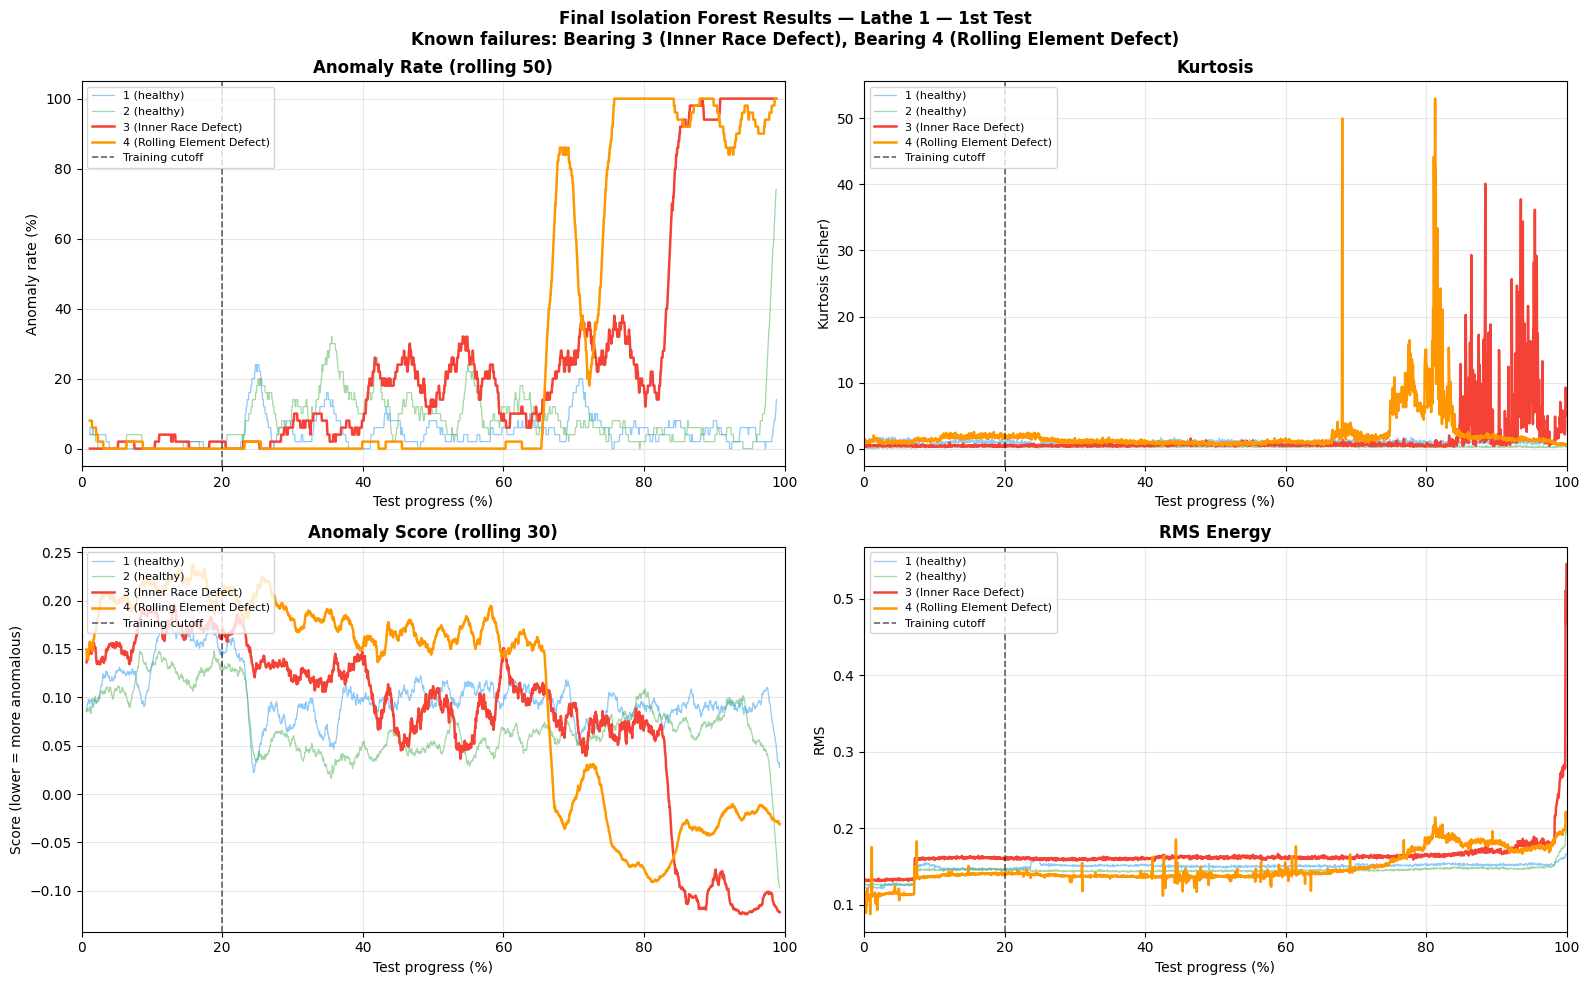

Saved: results\isolation_forest\lathe_1\lathe_1_final_results.png


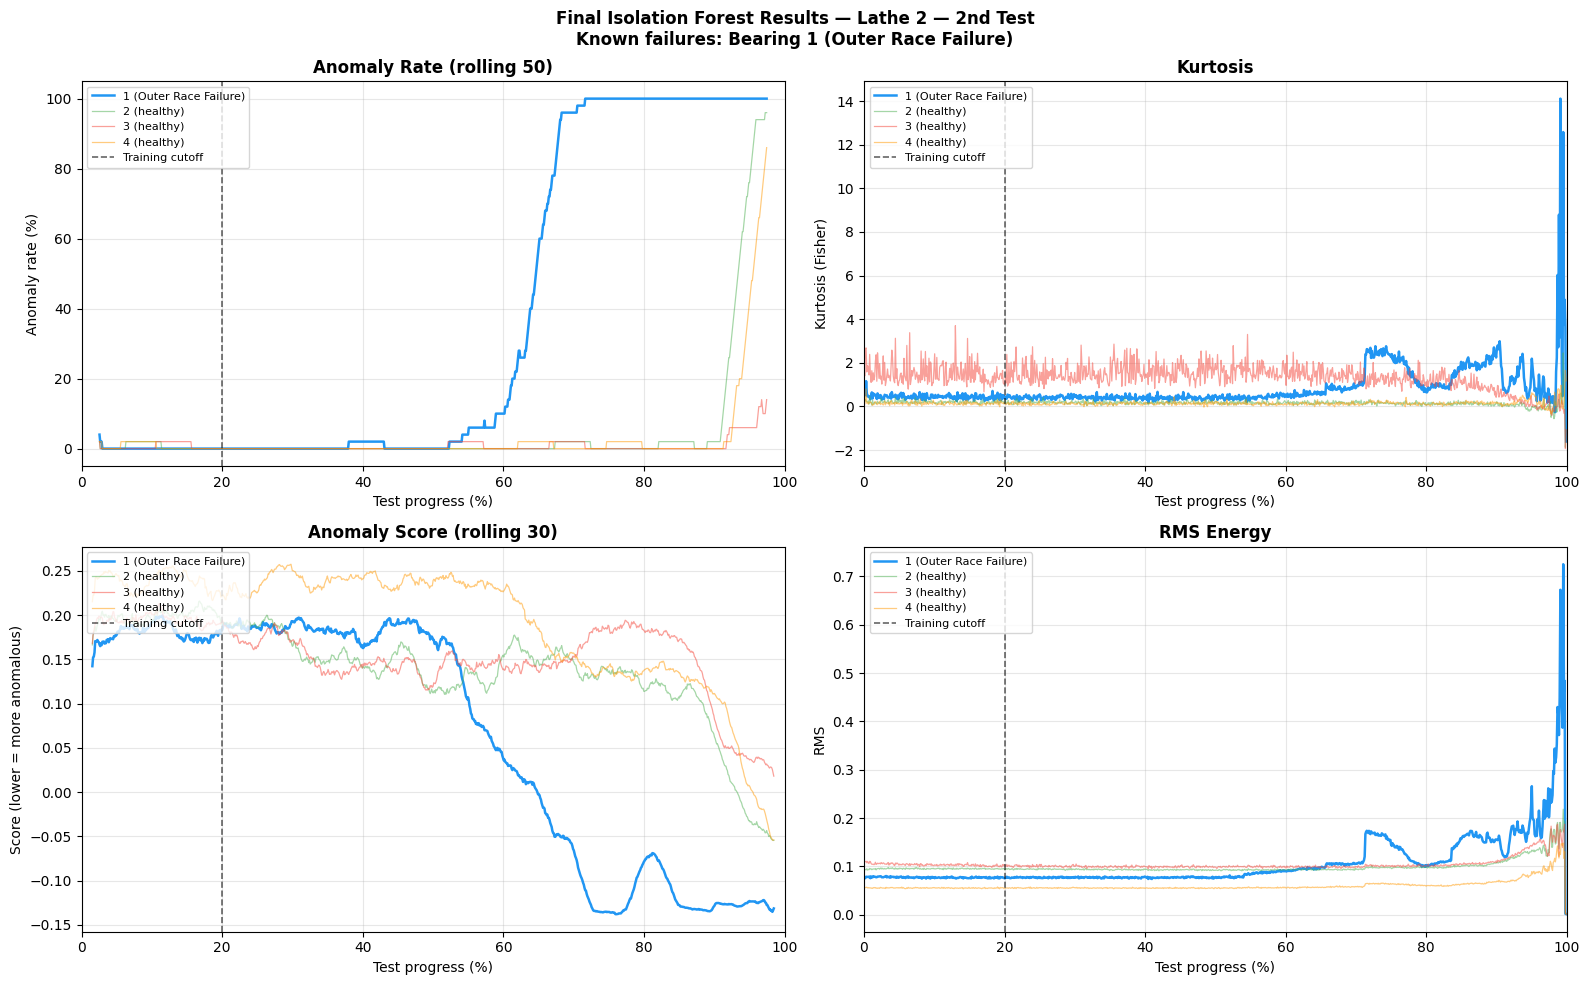

Saved: results\isolation_forest\lathe_2\lathe_2_final_results.png


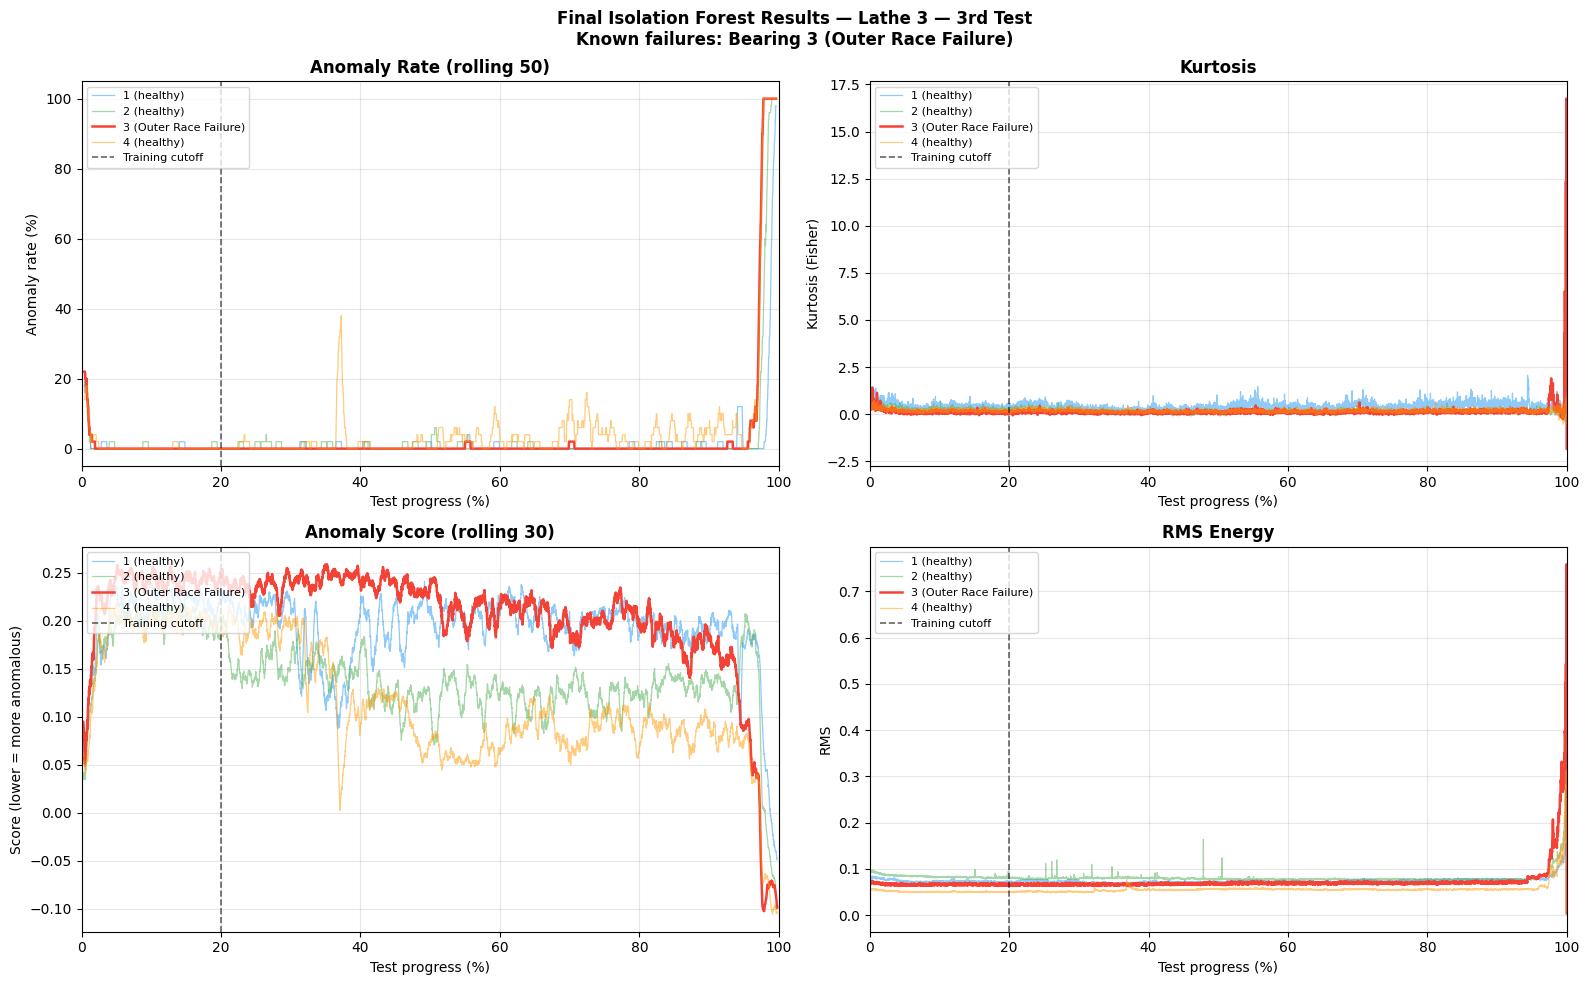

Saved: results\isolation_forest\lathe_3\lathe_3_final_results.png


In [37]:
# final summary plots for each lathe
for tc in TEST_CASES:
    lathe_name     = tc['name']
    known_failures = tc['known_failures']
    lathe_dir      = OUTPUT_DIR / lathe_name
    split_pct      = TRAIN_SPLIT * 100

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    failure_str = ', '.join([f"Bearing {b[-1]} ({v})" for b, v in known_failures.items()])
    fig.suptitle(f'Final Isolation Forest Results — {tc["label"]}\nKnown failures: {failure_str}',
                 fontsize=12, fontweight='bold')

    def add_cutoff(ax):
        ax.axvline(x=split_pct, color='black', linestyle='--',
                   linewidth=1.2, alpha=0.6, label='Training cutoff')

    for bearing_name, df in all_features[lathe_name].items():
        colour  = BEARING_COLOURS[bearing_name]
        is_fail = bearing_name in known_failures
        lw      = 1.8 if is_fail else 0.9
        alpha   = 1.0 if is_fail else 0.5
        label   = f"{bearing_name[-1]} ({known_failures.get(bearing_name, '')})" if is_fail else f"{bearing_name[-1]} (healthy)"

        results_df    = pd.read_csv(lathe_dir / f'{bearing_name}_results.csv')
        scores_smooth = pd.Series(results_df['anomaly_score']).rolling(30, center=True).mean()
        anom_smooth   = pd.Series(results_df['is_anomaly'].astype(float)).rolling(50, center=True).mean() * 100

        axes[0, 0].plot(df['progress'], anom_smooth,   color=colour, lw=lw, alpha=alpha, label=label)
        axes[0, 1].plot(df['progress'], df['kurtosis'], color=colour, lw=lw, alpha=alpha, label=label)
        axes[1, 0].plot(df['progress'], scores_smooth, color=colour, lw=lw, alpha=alpha, label=label)
        axes[1, 1].plot(df['progress'], df['rms'],      color=colour, lw=lw, alpha=alpha, label=label)

    for ax in axes.flat:
        add_cutoff(ax)
        ax.set_xlabel('Test progress (%)')
        ax.set_xlim(0, 100)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8, loc='upper left')

    axes[0, 0].set_title('Anomaly Rate (rolling 50)', fontweight='bold')
    axes[0, 0].set_ylabel('Anomaly rate (%)')
    axes[0, 1].set_title('Kurtosis', fontweight='bold')
    axes[0, 1].set_ylabel('Kurtosis (Fisher)')
    axes[1, 0].set_title('Anomaly Score (rolling 30)', fontweight='bold')
    axes[1, 0].set_ylabel('Score (lower = more anomalous)')
    axes[1, 1].set_title('RMS Energy', fontweight='bold')
    axes[1, 1].set_ylabel('RMS')

    plt.tight_layout()
    out = lathe_dir / f'{lathe_name}_final_results.png'
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {out}')

In [38]:
# verify all model files saved correctly
print('Model bundle verification:')
print('=' * 70)
for tc in TEST_CASES:
    lathe_name = tc['name']
    lathe_dir  = OUTPUT_DIR / lathe_name
    print(f"\n{tc['label']} -> {lathe_dir}")
    for bearing_name in tc['bearings']:
        model_path = lathe_dir / f'{bearing_name}_model.pkl'
        size_kb    = model_path.stat().st_size / 1024
        with open(model_path, 'rb') as f:
            bundle = pickle.load(f)
        print(f'  {model_path.name:<25} {size_kb:>7.1f} KB  '
              f'features={len(bundle["feature_names"])}  '
              f'train_n={bundle["n_train_samples"]}')

print('\nAll bundles verified.')

Model bundle verification:

Lathe 1 — 1st Test -> results\isolation_forest\lathe_1
  bearing1_model.pkl         1248.5 KB  features=11  train_n=431
  bearing2_model.pkl         1275.7 KB  features=11  train_n=431
  bearing3_model.pkl         1199.7 KB  features=11  train_n=431
  bearing4_model.pkl         1025.8 KB  features=11  train_n=431

Lathe 2 — 2nd Test -> results\isolation_forest\lathe_2
  bearing1_model.pkl          976.2 KB  features=11  train_n=196
  bearing2_model.pkl          941.0 KB  features=11  train_n=196
  bearing3_model.pkl          997.7 KB  features=11  train_n=196
  bearing4_model.pkl          883.1 KB  features=11  train_n=196

Lathe 3 — 3rd Test -> results\isolation_forest\lathe_3
  bearing1_model.pkl         1052.6 KB  features=11  train_n=1264
  bearing2_model.pkl         1061.5 KB  features=11  train_n=1264
  bearing3_model.pkl          973.2 KB  features=11  train_n=1264
  bearing4_model.pkl         1067.9 KB  features=11  train_n=1264

All bundles verified